In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [2]:
import joblib
path = '..\\data\\meteo_data.pkl'
meteo_data = joblib.load(path)

In [3]:
dictio = pd.read_csv("..\\data\\variables_description.csv")
dictio.index = dictio['variable']
#dictio

In [4]:
df = meteo_data['df']
VAR = meteo_data['VAR']
dummies_vars = meteo_data['dumies_vars']
selected_features = meteo_data['df']
IDS = meteo_data['IDS']
TARGET = meteo_data['TARGET']

In [16]:
df[IDS+['time_to_next_cg20']]

,lightning_id,lightning_airport_id,date,lon,lat,airport,airport_alert_id,time_to_next_cg20
date,,,,,,,,
2016-01-02 14:53:36+00:00,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,Ajaccio,NaN,3600.0
2016-01-02 14:53:36+00:00,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,Ajaccio,NaN,3600.0
2016-01-02 21:22:53+00:00,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,Ajaccio,NaN,0.0
2016-01-02 21:22:53+00:00,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,Ajaccio,1.0,0.0
2016-01-02 21:24:46+00:00,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,Ajaccio,1.0,0.0
...,...,...,...,...,...,...,...,...
2022-12-11 08:02:59+00:00,628717,156709,2022-12-11 08:02:59+00:00,10.4587,43.8370,Pise,769.0,0.0
2022-12-11 08:05:14+00:00,628718,156710,2022-12-11 08:05:14+00:00,10.6980,43.7691,Pise,NaN,1175.0
2022-12-11 08:07:12+00:00,628719,156711,2022-12-11 08:07:12+00:00,10.7095,43.7648,Pise,NaN,1057.0


In [5]:
df['time_to_next_cg20'].quantile([0.84, 0.85, 0.86, 0.87, 0.88, 0.89])


0.84     652.0
0.85     753.0
0.86     878.0
0.87    1035.0
0.88    1233.0
0.89    1500.0
Name: time_to_next_cg20, dtype: float64

In [6]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_10min_cg20'] = df['time_to_next_cg20'] > (10 * 60) # LE prochain arrive dans moins de 10 minutes


In [7]:
df["mois_annee"] = df["date"].dt.strftime("%Y-%m")
df['next_30min_cg20'] = df['time_to_next_cg20'] > (30 * 60) # LE prochain arrive dans moins de 10 minutes
df['next_30min_cg20'].value_counts()

next_30min_cg20
False    455410
True      51624
Name: count, dtype: int64

In [8]:
df.groupby("season")["next_30min_cg20"].sum()

season
Automne      12855
Hiver         2847
Printemps     8312
Été          27610
Name: next_30min_cg20, dtype: int64

## Séparation en train, test et OOT

Le developpement du score se fera sur une période : entre **2019--2021** et **2022** la validation hors temps




In [9]:
from sklearn.model_selection import train_test_split
target_col = 'next_30min_cg20'
data = df
# Combine the two columns for stratification
dev_mask = (df['year'] >= 2015) & (df['year'] <= 2020)
stratify_col = (data[target_col].astype(str)+ "_" + data['airport'] + "_" + data['month'].astype(str))[dev_mask]
train_data, test_data = train_test_split(
	data[dev_mask], 
	test_size=0.2, 
	random_state=42, 
	stratify=stratify_col
)
train_data, test_data = train_data.reset_index(drop=True), test_data.reset_index(drop=True)
oot_data = data[data['year'] >= 2021].reset_index(drop=True)
train_data.shape, test_data.shape, oot_data.shape

((312856, 104), (78214, 104), (115964, 104))

In [10]:
X_train = train_data[VAR+["airport",'season']].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[VAR+["airport",'season']].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[VAR+["airport",'season']].copy()
y_oot = oot_data[target_col].copy()*1

# Un premier score benchmark

In [11]:
top_var = ['min_dist_10min', 'min_dist_1min', 'log_cg_count_10min', 'log_cg_count_5min', 'log_count_5min', 'log_count_10min', 'log_cg_count_20min', 'std_azimuth_1min', 'mean_dist_5min', 'log_count_20min', 'std_azimuth_10min', 'rate_trend', 'mean_dist_1min', 'log_count_1min', 'storm_spread', 'log_count_30min', 'mean_dist_10min', 'log_ic_count_5min', 'log_ic_count_10min', 'log_ic_count_20min', 'std_lon_10min', 'std_lat_10min', 'time_since_last_lightning2', 'burst_indicator', 'time_since_last_cloud_ground2', 'activity_decay', 'max_amplitude_10min', 'dist', 'max_amplitude_1min', 'mean_azimuth_1min', 'mean_azimuth_10min', 'storm_direction_change', 'distance_trend', 'season', 'cg_20km', 'alert_duration', 'azimuth', 'azimuth_change']
len(top_var)

38

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_vars = top_var
#  = ['log_cg_count_5min', 'log_count_5min', 'log_cg_count_10min',
#        'mean_dist_5min', 'cg_20km', 'min_dist_1min', 'log_count_1min',
#        'min_dist_5min', 'log_ic_count_5min', 'mean_dist_10min',
#        'mean_dist_1min', 'hour', 'log_cg_count_20min', 'storm_spread',
#        'min_dist_10min', 'mean_azimuth_10min', 'log_count_30min',
#        'mean_azimuth_1min', 'time_since_last_lightning2',
#        'storm_center_distance']#VAR+["airport",'season'] 

X_train = train_data[xgb_vars].copy()
y_train = train_data[target_col].copy()*1
X_test = test_data[xgb_vars].copy()
y_test = test_data[target_col].copy()*1
X_oot = oot_data[xgb_vars].copy()
y_oot = oot_data[target_col].copy()*1
combined = pd.concat([X_train, X_test,X_oot], keys=['train', 'test','oot'])
combined_enc = pd.get_dummies(combined)

#Séparer avec les mêmes colonnes
X_train_enc = combined_enc.xs('train')#
X_test_enc = combined_enc.xs('test')
X_oot_enc = combined_enc.xs('oot')



In [15]:
# import optuna
# import lightgbm as lgb
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# def objective(trial):
#     params = {
#         "objective":        "binary",
#         "metric":           "auc",
#         "random_state":     42,
#         "verbose":          -1,
#         "n_estimators":     trial.suggest_int("n_estimators", 100, 800),
#         "max_depth":        trial.suggest_int("max_depth", 3, 8),
#         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "min_split_gain":   trial.suggest_float("min_split_gain", 0, 15),
#         "min_child_samples":trial.suggest_int("min_child_samples", 1, 20),
#         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
#         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
#         "num_leaves":       trial.suggest_int("num_leaves", 20, 150),
#     }

#     model = lgb.LGBMClassifier(**params)
#     scores = cross_val_score(model, X_train_enc, y_train,
#                              cv=cv, scoring="roc_auc", n_jobs=-1)
#     return scores.mean()

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# print(f"Meilleur AUC CV : {study.best_value:.4f}")
# print("Meilleurs paramètres :")
# study.best_params


Best trial: 7. Best value: 0.976931: 100%|██████████| 20/20 [06:59<00:00, 20.97s/it]

Meilleur AUC CV : 0.9769
Meilleurs paramètres :


{'n_estimators': 579,
 'max_depth': 8,
 'learning_rate': 0.014751470271914886,
 'subsample': 0.884687718567821,
 'colsample_bytree': 0.9936660425629327,
 'min_split_gain': 0.41570865318877936,
 'min_child_samples': 13,
 'reg_alpha': 0.001472816300064599,
 'reg_lambda': 0.027771275545525234,
 'num_leaves': 113}

In [ ]:
import lightgbm as lgb

params_lgb = {
    'n_estimators':      693,
    'max_depth':         7,
    'learning_rate':     0.1379299874272608,
    'subsample':         0.8304350260888248,
    'colsample_bytree':  0.8358669390869309,
    'min_child_samples': 12,   # équivalent min_child_weight
    'reg_alpha':         0.012356963127611184,
    'reg_lambda':        0.027308979970866187,
    # gamma n'existe pas en LightGBM → remplacé par min_split_gain
    'min_split_gain':    0.07500409612902384,
}

model_lgb = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    random_state=42,
    **params_lgb
)

model_lgb.fit(
    X_train_enc, y_train,
    eval_set=[(X_test_enc, y_test)]
    callbacks=[lgb.early_stopping(50, verbose=True)]
)


[LightGBM] [Info] Number of positive: 31323, number of negative: 281533
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8834
[LightGBM] [Info] Number of data points in the train set: 312856, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100120 -> initscore=-2.195897
[LightGBM] [Info] Start training from score -2.195897
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.1379299874272608
,n_estimators,693
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.07500409612902384
,min_child_weight,0.001
,min_child_samples,12


In [14]:
from sklearn.metrics import average_precision_score
y_pred = model_lgb.predict(X_oot_enc)
print(classification_report(y_oot, y_pred))

proba_train = model_lgb.predict_proba(X_train_enc)[:, 1]
proba_test  = model_lgb.predict_proba(X_test_enc)[:, 1]
proba_oot  = model_lgb.predict_proba(X_oot_enc)[:, 1]

prevalence = y_test.mean()

auc_train   = roc_auc_score(y_train, proba_train)
gini_train  = 2 * auc_train - 1

auc_test    = roc_auc_score(y_test, proba_test)
auc_pr_test = average_precision_score(y_test, proba_test)
rp          = auc_pr_test / prevalence
gini_test  = 2 * auc_test - 1

auc_oot    = roc_auc_score(y_oot, proba_oot)
auc_pr_oot = average_precision_score(y_oot, proba_oot)
rp_o          = auc_pr_oot / y_oot.mean()
gini_oot  = 2 * auc_oot - 1
print(f"ROC AUC TRAIN: {auc_train:.4f}  |  Gini TRAIN: {gini_train:.4f}")
print(f"ROC AUC TEST:  {auc_test:.4f} |  Gini Test: {gini_test:.4f}")
print(f"PR AUC TEST:   {auc_pr_test:.4f}  |  Ratio RP: {rp:.4f}")
print(f"ROC AUC OOT:  {auc_oot:.4f} |  Gini OOT: {gini_oot:.4f}")
print(f"PR AUC OOT:   {auc_pr_oot:.4f}  |  Ratio RP OOT: {rp_o:.4f}")


              precision    recall  f1-score   support

           0       0.94      0.97      0.95    103492
           1       0.62      0.45      0.52     12472

    accuracy                           0.91    115964
   macro avg       0.78      0.71      0.74    115964
weighted avg       0.90      0.91      0.90    115964

ROC AUC TRAIN: 0.9977  |  Gini TRAIN: 0.9954
ROC AUC TEST:  0.9909 |  Gini Test: 0.9819
PR AUC TEST:   0.9202  |  Ratio RP: 9.1934
ROC AUC OOT:  0.9220 |  Gini OOT: 0.8440
PR AUC OOT:   0.5740  |  Ratio RP OOT: 5.3372


In [35]:
test_data['probas'] = proba_test
train_data['probas'] = proba_train
oot_data['probas'] = proba_oot
test_data['points'] = proba_test*1000
train_data['points'] = proba_train*1000
oot_data['points'] = proba_oot*1000

In [36]:
# import shap

# explainer = shap.TreeExplainer(model_xgb)
# shap_values = explainer.shap_values(X_train)

# shp = shap.summary_plot(shap_values, X_train, plot_type="bar")


In [37]:
# # Importance = moyenne des |valeurs SHAP|
# importance = pd.Series(
#     np.abs(shap_values).mean(axis=0),
#     index=X_train_enc.columns
# ).sort_values(ascending=False)

# print(importance.to_string())

In [38]:
# feat_names = X_train.columns.tolist()
# shap.plots.violin(
#     shap_values,
#     features=X_train,
#     feature_names=feat_names,
#     plot_type="layered_violin",
#     max_display=20  # Limite à 20 variables les plus importantes
# )

# Analyse des performances

In [39]:
import sys
import os
from importlib import reload
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import analyser
from importlib import reload
reload(analyser)
train_analyser= analyser.Analyser(X=train_data,target_col=target_col)
test_analyser= analyser.Analyser(X=test_data,target_col=target_col)
oot_analyser= analyser.Analyser(X=oot_data,target_col=target_col)

## AUC maské

In [40]:
from sklearn.metrics import roc_auc_score, average_precision_score

def eval_on_mask(df, mask, y_col, proba_col):
    """
    Calcule GINI, ROC AUC et Ratio RP (PR AUC / prevalence) sur un sous-ensemble du DataFrame.

    Paramètres
    ----------
    df        : DataFrame complet
    mask      : condition booléenne, ex: df['airport'] == 'PAU'
    y_col     : nom de la colonne cible (0/1)
    proba_col : nom de la colonne de probabilités prédites

    Retourne
    --------
    dict avec les métriques
    """
    subset = df[mask]

    if len(subset) == 0:
        print("Masque vide — aucune ligne ne vérifie la condition.")
        return None

    y     = subset[y_col]
    proba = subset[proba_col]

    if y.nunique() < 2:
        print(f"Une seule classe présente dans le sous-ensemble ({len(subset)} lignes) — AUC indéfinie.")
        return None

    prevalence  = y.mean()
    auc         = roc_auc_score(y, proba)
    gini        = 2 * auc - 1
    auc_pr      = average_precision_score(y, proba)
    rp          = auc_pr / prevalence

    # print(f"Sous-ensemble : {len(subset)} lignes  |  Prevalence : {prevalence:.3%}")
    # print(f"ROC AUC : {auc:.4f}  |  Gini : {gini:.4f}")
    # print(f"PR AUC  : {auc_pr:.4f}  |  Ratio RP : {rp:.4f}")

    return {"n": len(subset), "prevalence": prevalence,
            "auc": auc, "gini": gini, "auc_pr": auc_pr, "rp": rp}


### par aeroport

In [41]:
def auc_mask(train_data,col = "airport"):
    results = []
    for airport in train_data[col].unique():
        mask = train_data[col] == airport
        metrics = eval_on_mask(train_data, mask=mask, y_col=target_col, proba_col='probas')
        if metrics:
            metrics[col] = airport
            results.append(metrics)

    df_results = (pd.DataFrame(results)
                    .set_index(col)
                    [['n', 'prevalence', 'auc', 'gini', 'auc_pr', 'rp']]
                    .sort_values('rp', ascending=False))
    return df_results
    # df_results.style.format({
    #     'prevalence': '{:.2%}',
    #     'auc':        '{:.4f}',
    #     'gini':       '{:.4f}',
    #     'auc_pr':     '{:.4f}',
    #     'rp':         '{:.2f}',
    # }).background_gradient(subset=['auc', 'gini', 'rp'], cmap='RdYlGn')


In [42]:
auc_mask(train_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Nantes,21548,0.089753,0.999072,0.998145,0.989968,11.029898
Bastia,77594,0.096760,0.999440,0.998880,0.994684,10.279908
Biarritz,72297,0.097985,0.999545,0.999091,0.995802,10.162829
Ajaccio,43190,0.098171,0.998656,0.997312,0.986738,10.051225
Pise,98227,0.107476,0.999499,0.998997,0.995689,9.264334


In [43]:
auc_mask(test_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Nantes,5389,0.089627,0.990779,0.981558,0.907427,10.124483
Bastia,19397,0.096819,0.994559,0.989117,0.949428,9.806208
Biarritz,18074,0.097986,0.994193,0.988385,0.946787,9.662468
Ajaccio,10798,0.097981,0.985008,0.970015,0.859016,8.767155
Pise,24556,0.107469,0.991437,0.982873,0.928190,8.636848


In [44]:
auc_mask(oot_data)

,n,prevalence,auc,gini,auc_pr,rp
airport,,,,,,
Bastia,28926,0.101397,0.951555,0.903109,0.609477,6.010823
Biarritz,24805,0.096795,0.897868,0.795736,0.520660,5.378994
Ajaccio,18512,0.111387,0.934484,0.868969,0.570294,5.119924
Nantes,9791,0.111837,0.925158,0.850316,0.552198,4.937504
Pise,33930,0.117330,0.903776,0.807552,0.556257,4.740968


### par saison

In [45]:
auc_mask(train_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Automne,90239,0.085750,0.999234,0.998469,0.991619,11.564063
Été,183911,0.087461,0.999648,0.999297,0.996282,11.391183
Printemps,31337,0.180298,0.998397,0.996794,0.992232,5.503290
Hiver,7369,0.251052,0.996347,0.992694,0.987651,3.934053


In [46]:
auc_mask(test_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Été,45977,0.087435,0.995588,0.991175,0.953444,10.904598
Automne,22560,0.085727,0.991277,0.982553,0.908722,10.600185
Printemps,7837,0.180299,0.976650,0.953300,0.889924,4.935832
Hiver,1840,0.251087,0.956254,0.912509,0.862807,3.436289


In [47]:
auc_mask(oot_data,col = 'season')

,n,prevalence,auc,gini,auc_pr,rp
season,,,,,,
Printemps,15821,0.078946,0.966514,0.933028,0.680111,8.614927
Automne,38851,0.081928,0.956698,0.913396,0.621751,7.588959
Été,58641,0.127982,0.880688,0.761375,0.504039,3.938353
Hiver,2651,0.201811,0.903097,0.806194,0.671915,3.329433


## KS stat

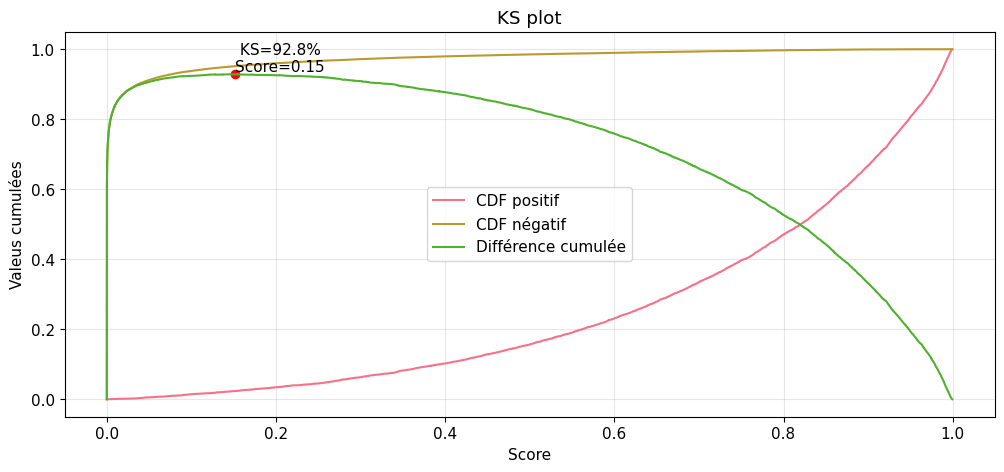

Discrimination forte (KS > 70%)


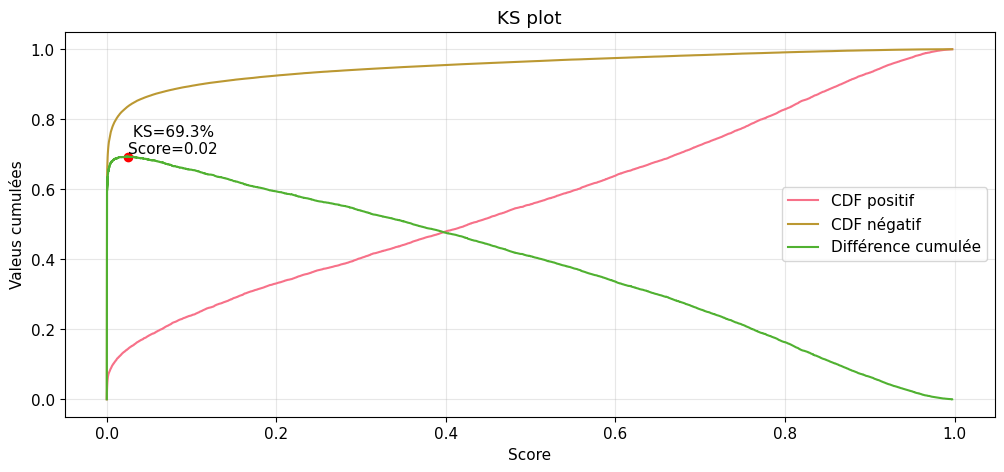

Discrimination correcte (40% < KS < 70%)


In [48]:
test_analyser.plot_ks()
oot_analyser.plot_ks()

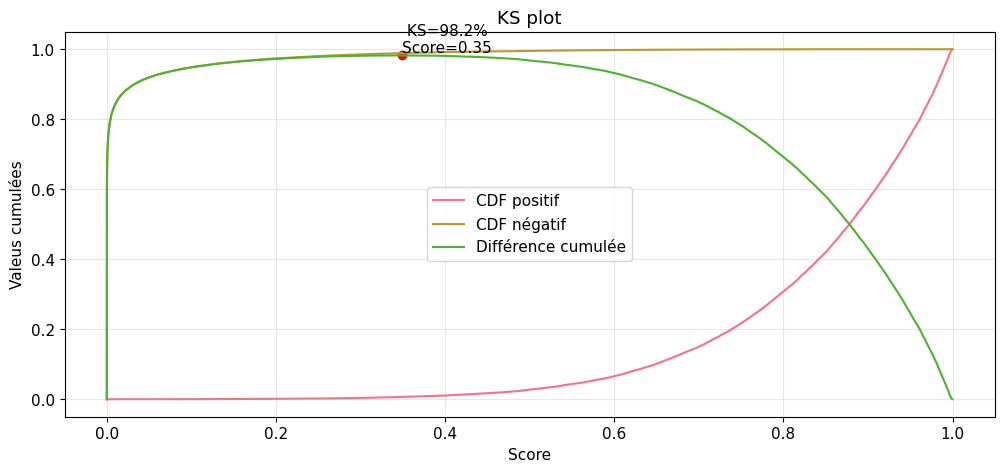

Discrimination forte (KS > 70%)


In [49]:
train_analyser.plot_ks()

## Reliability diagrams

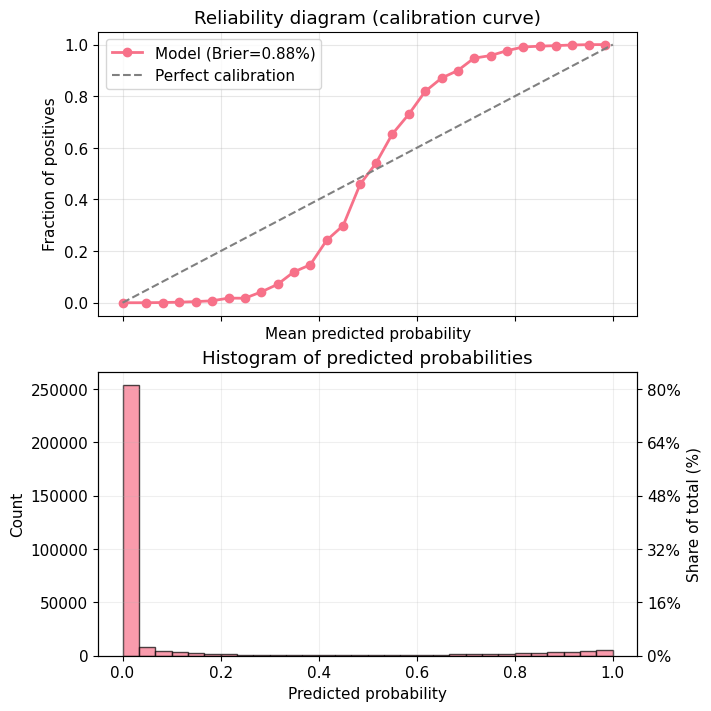

In [73]:
train_analyser.reliability_diagram(n_bins=30)

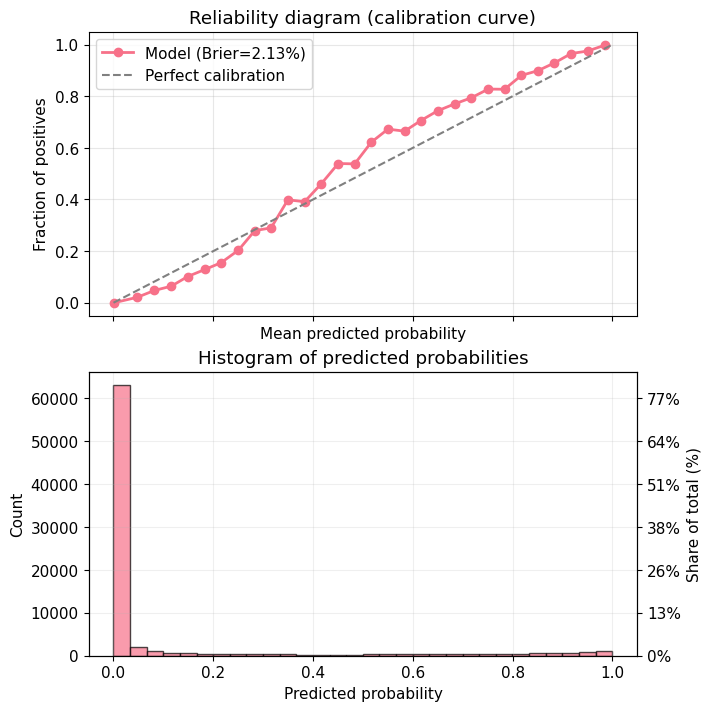

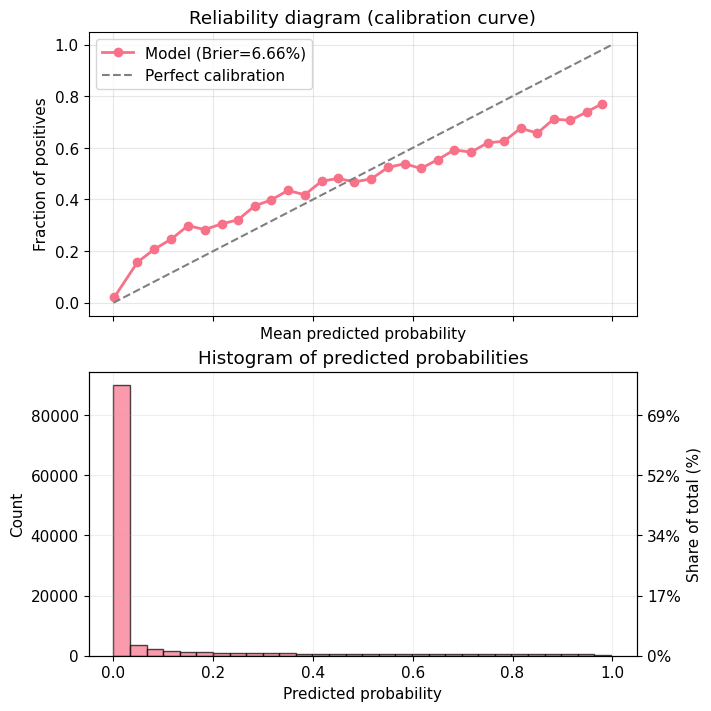

In [72]:
test_analyser.reliability_diagram(n_bins=30)
oot_analyser.reliability_diagram(n_bins=30)

## quelques plots

In [51]:
def construire_part_df(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=-1):
    """
    Constructs a dataframe of good/bad proportions by score interval.
    
    df : input dataframe
    score_col : name of the score column
    label_col : column containing default indicator (0/1)
    pas : grouping step for scores (e.g., 20 points)
    """
    
    # 1. Create rounded column
    df = df[[score_col, label_col]].copy()
    if pas==-1:
        df["score_round"] =df[score_col]# 
    else : 
        df["score_round"] = (df[score_col] / pas).round(rnd) * pas
        df["score_round"] = df["score_round"].astype(int)
    
    # 2. Calculate total counts and counts by class
    part_df = df.groupby("score_round").agg(
        nb_total    = (label_col, "size"),
        nb_non_default = (label_col, lambda x: (x == 0).sum()),  # Assuming 0 = no default
        nb_default      = (label_col, lambda x: (x == 1).sum())   # Assuming 1 = default
    ).reset_index()
    
    # 3. Calculate proportions
    part_df["non_default"] = part_df["nb_non_default"] / part_df["nb_total"]
    part_df["default"]  = part_df["nb_default"] / part_df["nb_total"]
    
    return part_df

def score_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=0, pas=20):
    """
    Creates a stacked bar chart of default vs non-default by score interval.
    Displays default rate on each bar.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Calculate default rate for each interval
    part_df['default_rate'] = part_df['default'] / (part_df['non_default'] + part_df['default'])
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot stacked bars
    bars = part_df[['non_default', 'default']].plot(
        ax=ax,
        kind='bar',
        stacked=True,
        legend=False,
        color=['#e74c3c','#2ecc71'],  # Green for non-default, red for default
        width=0.7
    )
    
    # Add legend
    ax.legend(['CG20 imminent', 'Last CG20'], loc='upper left', bbox_to_anchor=(1, 1))
    
    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # Format x-axis
    ax.set_xticklabels([str(int(x)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis if needed
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels and title
    ax.set_xlabel('Score (/1000)', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.set_title(f'Distribution of last CG by score intervals (step={pas})', fontsize=14, fontweight='bold')
    
    # Add default rate labels on each bar
    for i, (idx, row) in enumerate(part_df.iterrows()):
        # Position for the label (middle of the default segment)
        x_pos = i
        y_pos = row['non_default'] + row['default'] / 2
        
        # Add default rate label
        ax.text(x_pos, y_pos, 
                f"DR: {row['default_rate']:.1%}", 
                ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white',
                #bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        # Add number of observations below the bar
        total_obs = int(row['nb_total'])
        ax.text(x_pos, -0.05, 
                f"n={total_obs:,}", 
                ha='center', va='top', 
                fontsize=9, rotation=0,
                color='dimgray')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display summary statistics
    print("\n" + "="*60)
    print("SUMMARY BY SCORE INTERVAL")
    print("="*60)
    summary = part_df[['score_round', 'nb_total', 'nb_non_default', 'nb_default', 'default_rate']].copy()
    summary['default_rate'] = summary['default_rate'].apply(lambda x: f"{x:.2%}")
    summary.columns = ['Score', 'Total', 'Non-default', 'Default', 'Default Rate']
    print(summary.to_string(index=False))

def probas_graph_empile(df, score_col='points', label_col='default_t_plus_1', rnd=5, pas=0.01):
    """
    Creates a stacked bar chart of default vs non-default by predicted probability intervals.
    """
    # Build the distribution dataframe
    part_df = construire_part_df(df, score_col, label_col, rnd=rnd, pas=pas)
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    part_df[['non_default', 'default']].plot(
        ax=ax, 
        kind='bar', 
        stacked=True,
        color=['#2ecc71', '#e74c3c']
    )
    
    # Format yticks as percentages
    ax.set_yticklabels(['{:.1%}'.format(x) for x in ax.get_yticks()])
    
    # Format xticks with rotation
    ax.set_xticklabels([str(round(x, 2)) for x in part_df['score_round']], rotation=45, ha='right')
    
    # Reduce number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(20))
    
    # Add labels
    ax.set(xlabel='Predicted probabilities', ylabel='Proportion')
    ax.set_title('Distribution of default by predicted probability intervals', fontsize=14)
    ax.legend(['Non-default', 'Default'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return part_df



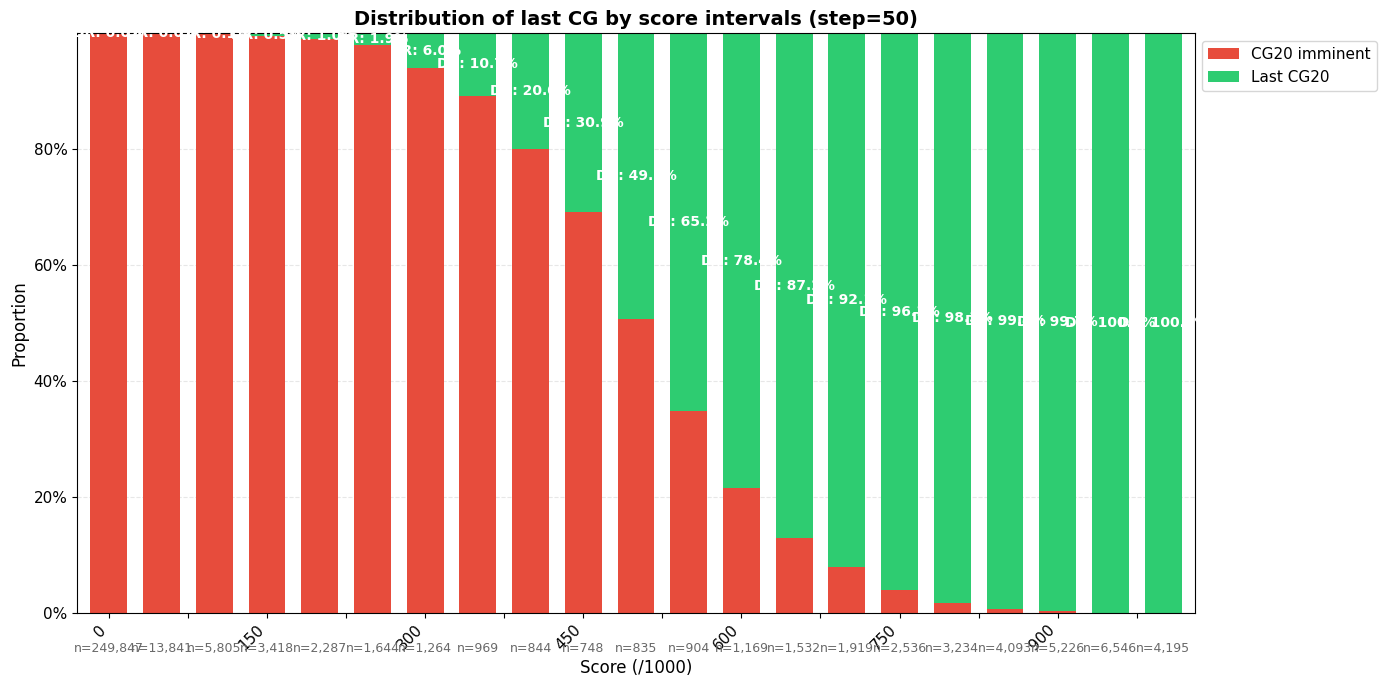


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0 249847       249846        1        0.00%
    50  13841        13839        2        0.01%
   100   5805         5797        8        0.14%
   150   3418         3400       18        0.53%
   200   2287         2263       24        1.05%
   250   1644         1612       32        1.95%
   300   1264         1188       76        6.01%
   350    969          865      104       10.73%
   400    844          675      169       20.02%
   450    748          517      231       30.88%
   500    835          423      412       49.34%
   550    904          315      589       65.15%
   600   1169          252      917       78.44%
   650   1532          196     1336       87.21%
   700   1919          152     1767       92.08%
   750   2536           99     2437       96.10%
   800   3234           54     3180       98.33%
   850   4093           24     4069       99.41%
   900   5226           15     5211       

In [52]:
score_graph_empile(train_data, score_col='points', label_col=target_col, pas=50)
#probas_graph_empile(train_data, score_col='points', label_col='default_t_plus_1', pas=0.05)

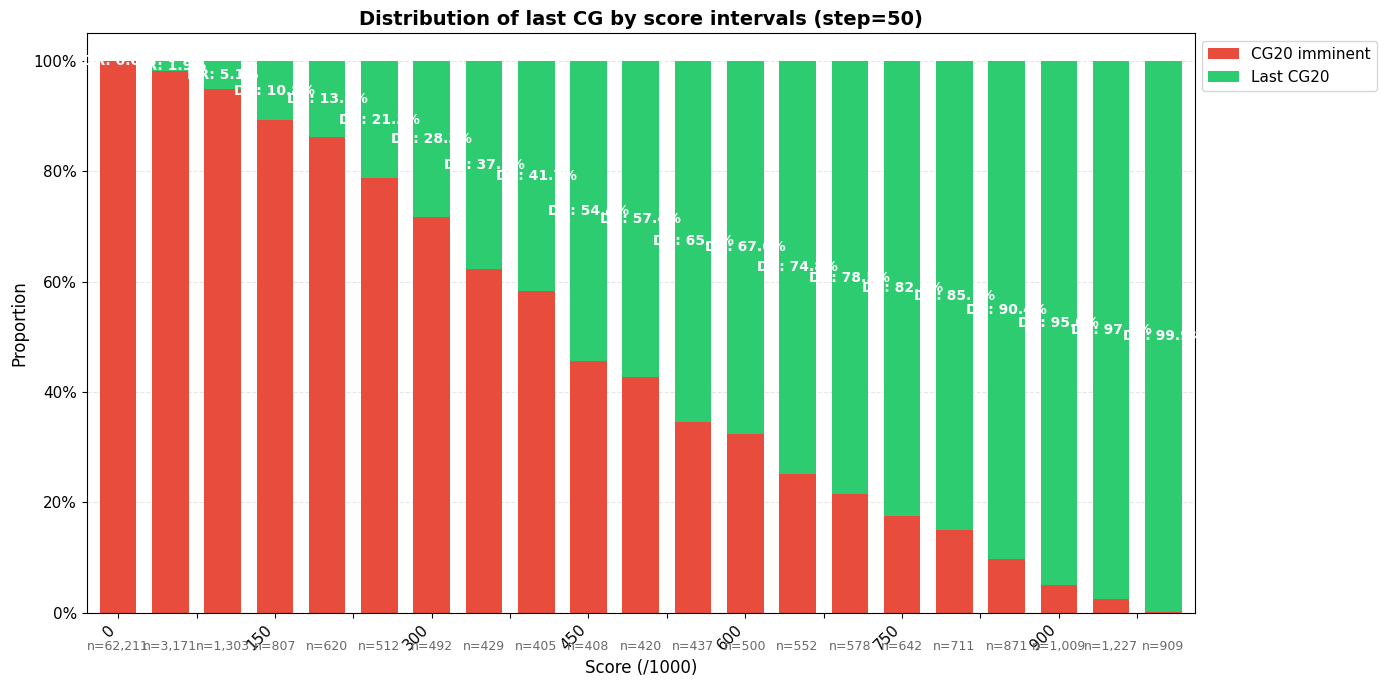


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  62211        62198       13        0.02%
    50   3171         3112       59        1.86%
   100   1303         1236       67        5.14%
   150    807          720       87       10.78%
   200    620          534       86       13.87%
   250    512          403      109       21.29%
   300    492          353      139       28.25%
   350    429          267      162       37.76%
   400    405          236      169       41.73%
   450    408          186      222       54.41%
   500    420          179      241       57.38%
   550    437          151      286       65.45%
   600    500          162      338       67.60%
   650    552          139      413       74.82%
   700    578          124      454       78.55%
   750    642          113      529       82.40%
   800    711          106      605       85.09%
   850    871           84      787       90.36%
   900   1009           50      959       

In [53]:
score_graph_empile(test_data, score_col='points', label_col=target_col, pas=50)


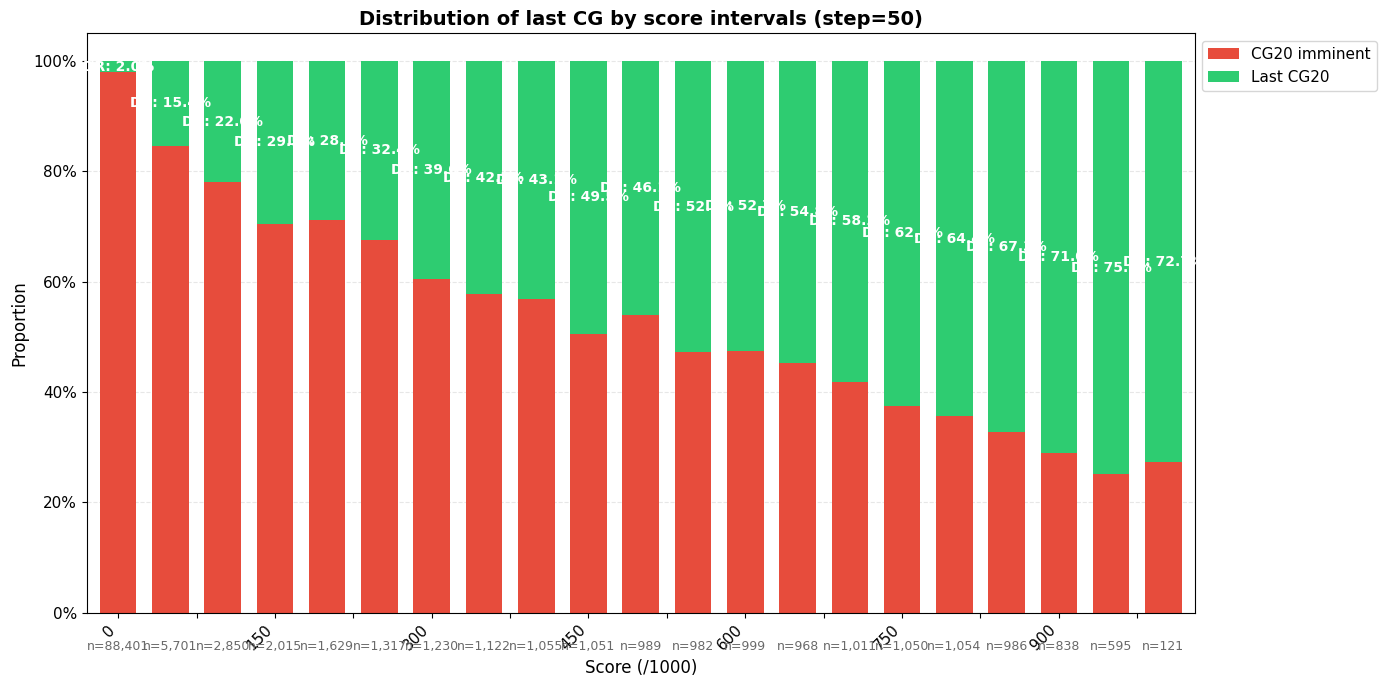


SUMMARY BY SCORE INTERVAL
 Score  Total  Non-default  Default Default Rate
     0  88401        86609     1792        2.03%
    50   5701         4824      877       15.38%
   100   2850         2224      626       21.96%
   150   2015         1420      595       29.53%
   200   1629         1158      471       28.91%
   250   1317          890      427       32.42%
   300   1230          743      487       39.59%
   350   1122          647      475       42.34%
   400   1055          600      455       43.13%
   450   1051          531      520       49.48%
   500    989          533      456       46.11%
   550    982          463      519       52.85%
   600    999          473      526       52.65%
   650    968          438      530       54.75%
   700   1011          423      588       58.16%
   750   1050          394      656       62.48%
   800   1054          375      679       64.42%
   850    986          322      664       67.34%
   900    838          243      595       

In [54]:
score_graph_empile(oot_data, score_col='points', label_col=target_col, pas=50)


# Première approche, trouver un seuil

## Seuil optimal F1

In [55]:
from sklearn.metrics import f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, proba_train)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_threshold = thresholds[f1_scores[:-1].argmax()]
print(f"Seuil optimal F1 : {best_threshold:.3f} | F1 : {f1_scores.max():.4f}")


Seuil optimal F1 : 0.489 | F1 : 0.9661


              precision    recall  f1-score   support

           0       0.98      0.98      0.98     70385
           1       0.86      0.85      0.85      7829

    accuracy                           0.97     78214
   macro avg       0.92      0.92      0.92     78214
weighted avg       0.97      0.97      0.97     78214



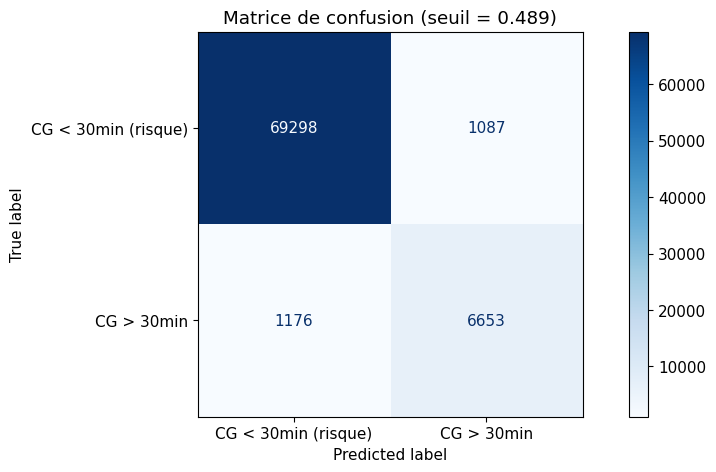

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.94      0.96      0.95    103492
           1       0.60      0.45      0.52     12472

    accuracy                           0.91    115964
   macro avg       0.77      0.71      0.73    115964
weighted avg       0.90      0.91      0.90    115964



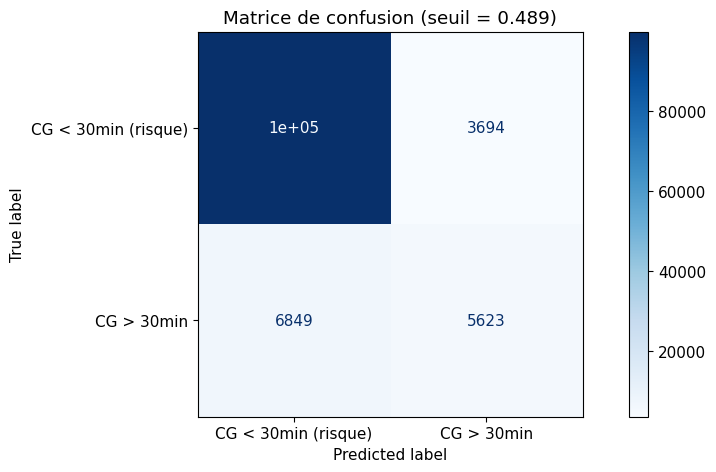

In [57]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


## Seuil optimal Youden

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, proba_train)
youden = tpr - fpr
best_threshold = thresholds[youden.argmax()]
print(f"Seuil optimal Youden : {best_threshold:.3f}")


Seuil optimal Youden : 0.349


              precision    recall  f1-score   support

           0       0.99      0.98      0.98     70385
           1       0.81      0.92      0.86      7829

    accuracy                           0.97     78214
   macro avg       0.90      0.95      0.92     78214
weighted avg       0.97      0.97      0.97     78214



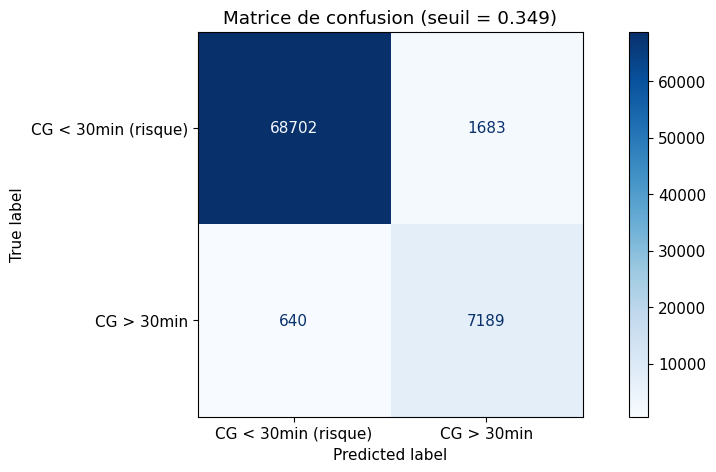

In [59]:
pred = (proba_test > best_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


              precision    recall  f1-score   support

           0       0.95      0.95      0.95    103492
           1       0.57      0.56      0.56     12472

    accuracy                           0.91    115964
   macro avg       0.76      0.75      0.76    115964
weighted avg       0.91      0.91      0.91    115964



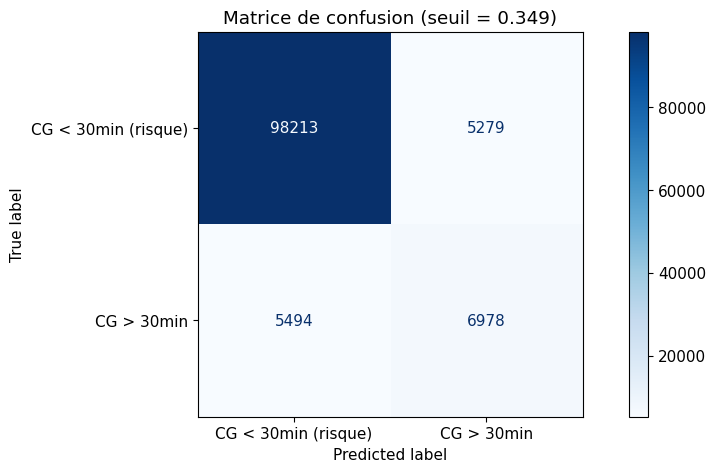

In [60]:
pred = (proba_oot > best_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()


# Recall et precision 

Seuil max précision (rappel ≥ 30%) : 0.913
  Précision : 0.9837
  Rappel    : 0.3008

Seuil max rappel (précision ≥ 30%) : 0.001
  Précision : 0.3000
  Rappel    : 1.0000


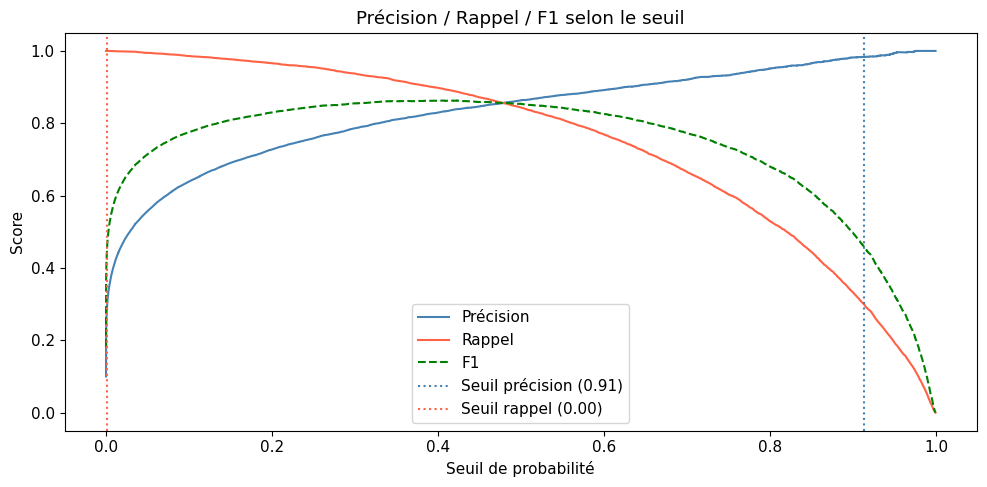

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)

# Seuil qui maximise la précision (minimise les fausses alarmes)
# Contrainte : rappel minimum acceptable (ex : 30%)
min_recall = 0.30
mask = recall[:-1] >= min_recall
if mask.any():
    best_precision_threshold = thresholds[mask][precision[:-1][mask].argmax()]
    print(f"Seuil max précision (rappel ≥ {min_recall:.0%}) : {best_precision_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_precision_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_precision_threshold):.4f}")

# Seuil qui maximise le rappel (minimise les CG manqués)
# Contrainte : précision minimum acceptable (ex : 30%)
min_precision = 0.30
mask = precision[:-1] >= min_precision
if mask.any():
    best_recall_threshold = thresholds[mask][recall[:-1][mask].argmax()]
    print(f"\nSeuil max rappel (précision ≥ {min_precision:.0%}) : {best_recall_threshold:.3f}")
    print(f"  Précision : {precision_score(y_test, proba_test >= best_recall_threshold):.4f}")
    print(f"  Rappel    : {recall_score(y_test, proba_test >= best_recall_threshold):.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Précision', color='steelblue')
plt.plot(thresholds, recall[:-1],    label='Rappel',    color='tomato')
plt.plot(thresholds, 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9),
         label='F1', color='green', linestyle='--')
plt.axvline(best_precision_threshold, color='steelblue', linestyle=':', label=f'Seuil précision ({best_precision_threshold:.2f})')
plt.axvline(best_recall_threshold,    color='tomato',    linestyle=':', label=f'Seuil rappel ({best_recall_threshold:.2f})')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.title('Précision / Rappel / F1 selon le seuil')
plt.legend()
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       0.93      1.00      0.96     70385
           1       0.98      0.30      0.46      7829

    accuracy                           0.93     78214
   macro avg       0.96      0.65      0.71     78214
weighted avg       0.93      0.93      0.91     78214



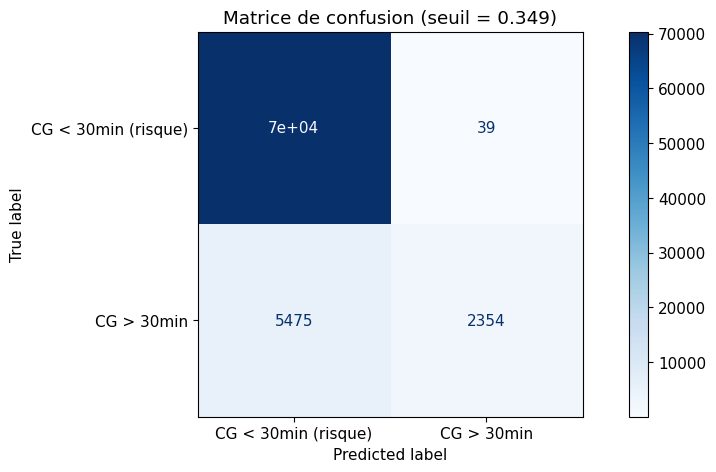

In [62]:
pred = (proba_test > best_precision_threshold).astype(int)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

              precision    recall  f1-score   support

           0       0.90      1.00      0.94    103492
           1       0.74      0.05      0.10     12472

    accuracy                           0.90    115964
   macro avg       0.82      0.53      0.52    115964
weighted avg       0.88      0.90      0.85    115964



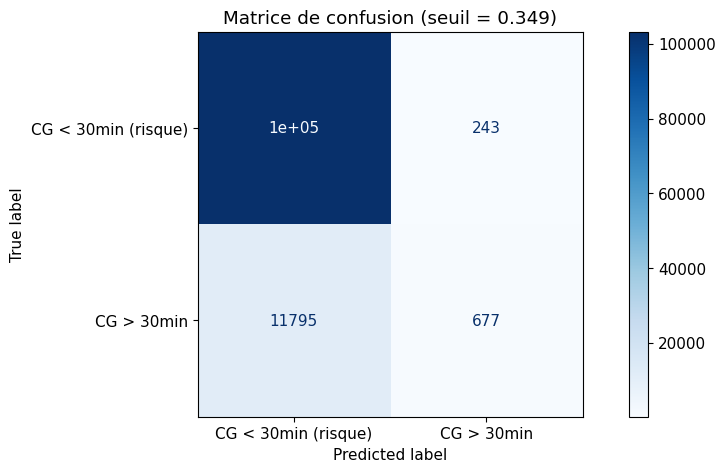

In [63]:
pred = (proba_oot > best_precision_threshold).astype(int)
print(classification_report(y_oot, pred))

cm = confusion_matrix(y_oot, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['CG < 30min (risque)', 'CG > 30min'])
disp.plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil = {best_threshold:.3f})')
plt.show()

# Construction des CHR (stabilité en risque et volume)

In [84]:
from src import binner
  # recharge le module avec les dernières modifications
reload(binner)
Binner = binner.Binner
cols = xgb_vars + ['year','probas',target_col,'points']
train_df = train_data[cols].copy()

test_df = test_data[cols].copy()
oot_df = oot_data[cols].copy()
Bin_train = Binner(X = train_df,cible_col=target_col,date_col='year')
Bin_test = Binner(X = test_df,cible_col=target_col,date_col='year')
Bin_oot = Binner(X = oot_df,cible_col=target_col,date_col='year')


In [65]:
def merge_modalities(bin_instance,mapping, col='CHR' ):
    bin_instance.merge_modalities(
        col=col,
        mapping=mapping
    )

def apply_breaks(bin_instance, breaks,var = 'CHR',upp=None,low=None):
    if var not in bin_instance.X.columns:
        bin_instance.X[var] = np.nan
    bin_instance.X[var] = bin_instance.X[var].astype(str)
    if low is not None and upp is not None:
        mask = (bin_instance.X['probas'] > low) & (bin_instance.X['probas'] <= upp)
    elif low is not None:
        mask = bin_instance.X['probas'] > low
    elif upp is not None:
        mask = bin_instance.X['probas'] <= upp
    else:
        mask = None
    if mask is not None:
        bin_instance.X.loc[mask,var] = pd.cut(
            bin_instance.X.loc[mask,'probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)
    else:
        bin_instance.X[var] = pd.cut(
            bin_instance.X['probas'],
            bins=breaks,
            include_lowest=True
        ).astype(str)

In [66]:
import pandas as pd
import numpy as np
import jenkspy

def jenks_prebinning(
    df,
    variable,
    target,
    n_bins=8,
    min_bin_pct=0.01
):
    """
    Jenks pre-binning for IRB (exploratory only)

    Parameters
    ----------
    df : DataFrame (TRAIN uniquement)
    variable : str, variable continue
    target : str, défaut (0/1)
    n_bins : int, nombre max de classes Jenks
    min_bin_pct : float, taille minimale d'un bin

    Returns
    -------
    df_bins : DataFrame avec stats par bin
    breaks : seuils Jenks
    """

    # Séparation missing / non-missing
    df_nm = df[[variable, target]].dropna()
    df_miss = df[df[variable].isna()]

    # Jenks sur non-missing uniquement
    values = df_nm[variable].values

    # Sécurité si peu de valeurs uniques
    n_bins_eff = min(n_bins, len(np.unique(values)) - 1)
    if n_bins_eff < 2:
        raise ValueError("Pas assez de valeurs uniques pour Jenks")

    breaks = jenkspy.jenks_breaks(values, n_classes=n_bins_eff)

    # Application des bins
    df_nm['bin_raw'] = pd.cut(
        df_nm[variable],
        bins=breaks,
        include_lowest=True
    )

    # Stats par bin
    bin_stats = (
        df_nm
        .groupby('bin_raw')[target]
        .agg(['count', 'sum'])
        .rename(columns={'count': 'n_obs', 'sum': 'defaults'})
    )

    bin_stats['dr'] = bin_stats['defaults'] / bin_stats['n_obs']
    bin_stats['pct_obs'] = bin_stats['n_obs'] / bin_stats['n_obs'].sum()

    # Flag bins trop petits
    bin_stats['small_bin_flag'] = bin_stats['pct_obs'] < min_bin_pct

    # Missing bin (séparé)
    if len(df_miss) > 0:
        miss_defaults = df_miss[target].sum()
        miss_n = len(df_miss)
        miss_dr = miss_defaults / miss_n

        bin_stats.loc['Missing', :] = [
            miss_n,
            miss_defaults,
            miss_dr,
            miss_n / len(df),
            False
        ]

    return bin_stats, breaks



## premier regroupement

In [ ]:
# desc , breaks = jenks_prebinning(df=train_df,
#     variable='probas',target=target_col,n_bins=12,
#     min_bin_pct=0.01)

In [ ]:
breaks = [np.float32(3.5241958e-09),
 np.float32(0.019335939),
 np.float32(0.06655301),
 np.float32(0.13352166),
 np.float32(0.21976413),
 np.float32(0.32749853),
 np.float32(0.4542161),
 np.float32(0.5824038),
 np.float32(0.69375753),
 np.float32(0.7861185),
 np.float32(0.86526424),
 np.float32(0.9361281),
 np.float32(0.9995296)]

[np.float32(3.5241958e-09),
 np.float32(0.019335939),
 np.float32(0.06655301),
 np.float32(0.13352166),
 np.float32(0.21976413),
 np.float32(0.32749853),
 np.float32(0.4542161),
 np.float32(0.5824038),
 np.float32(0.69375753),
 np.float32(0.7861185),
 np.float32(0.86526424),
 np.float32(0.9361281),
 np.float32(0.9995296)]

In [ ]:
# desc

,n_obs,defaults,dr,pct_obs,small_bin_flag
bin_raw,,,,,
"(-0.00099999648, 0.0193]",246435,0,0.000000,0.787695,False
"(0.0193, 0.0666]",15849,2,0.000126,0.050659,False
"(0.0666, 0.134]",7887,11,0.001395,0.025210,False
"(0.134, 0.22]",4793,35,0.007302,0.015320,False
"(0.22, 0.327]",3188,116,0.036386,0.010190,False
"(0.327, 0.454]",2211,392,0.177295,0.007067,True
"(0.454, 0.582]",2204,1221,0.553993,0.007045,True
"(0.582, 0.694]",3196,2727,0.853254,0.010216,False
"(0.694, 0.786]",4471,4275,0.956162,0.014291,False


In [85]:
apply_breaks(Bin_oot, breaks)
apply_breaks(Bin_test, breaks)
apply_breaks(Bin_train, breaks)

In [76]:
train_df.CHR.unique()

array(['(-0.00099999648, 0.0193]', '(0.134, 0.22]', '(0.327, 0.454]',
       '(0.936, 1.0]', '(0.0193, 0.0666]', '(0.0666, 0.134]',
       '(0.582, 0.694]', '(0.694, 0.786]', '(0.865, 0.936]',
       '(0.454, 0.582]', '(0.786, 0.865]', '(0.22, 0.327]'], dtype=object)

In [ ]:
# mapping = {
#     '(0.273, 0.375]' : '(0.273, 0.498]',
#     '(0.375, 0.498]' : '(0.273, 0.498]',
#     '(0.11, 0.184]' : '(0.11, 0.273]',
#     '(0.184, 0.273]' : '(0.11, 0.273]',
#     '(0.273, 0.498]' : '(0.273, 0.684]',
#     '(0.498, 0.684]' : '(0.273, 0.684]',
# }
# merge_modalities(Bin_train, mapping)
# merge_modalities(Bin_test, mapping)
# merge_modalities(Bin_oot, mapping)

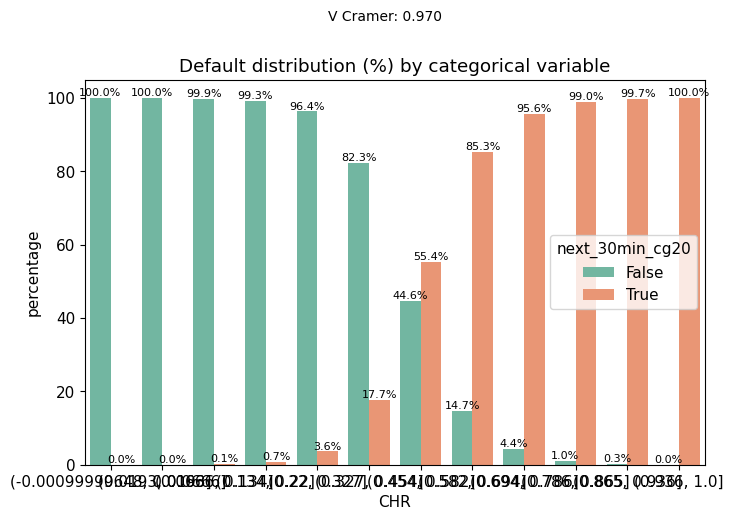

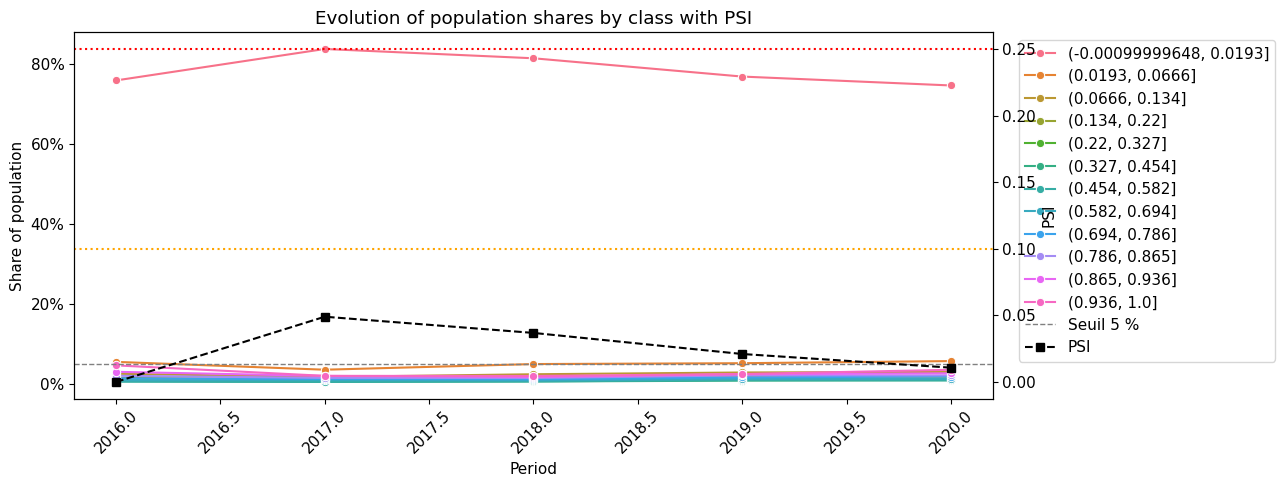

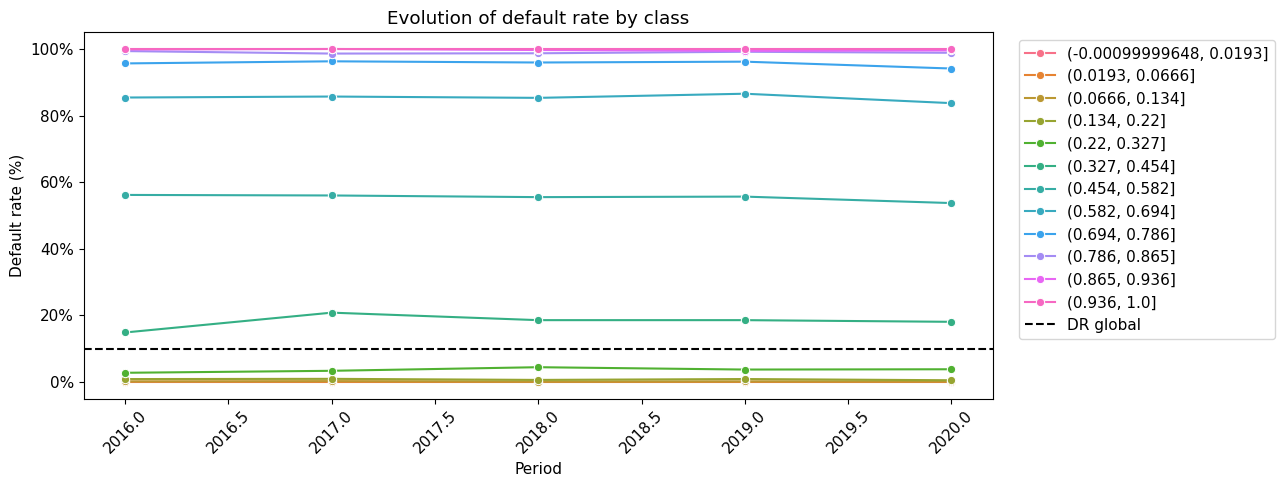

In [86]:
Bin_train.plot_categorical_distribution('CHR')
Bin_train.plot_bin_stability_over_time('CHR')

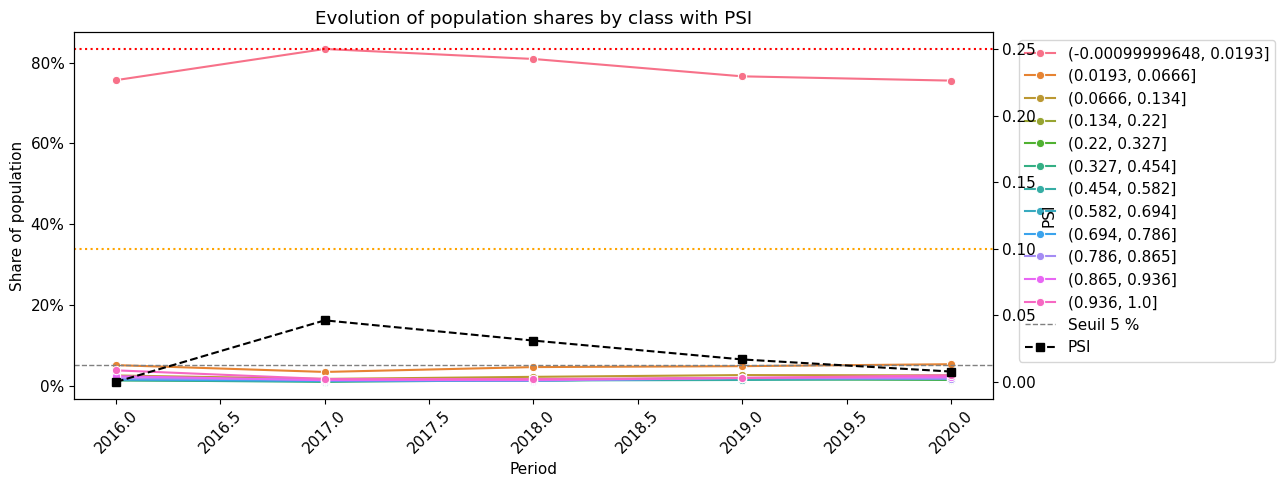

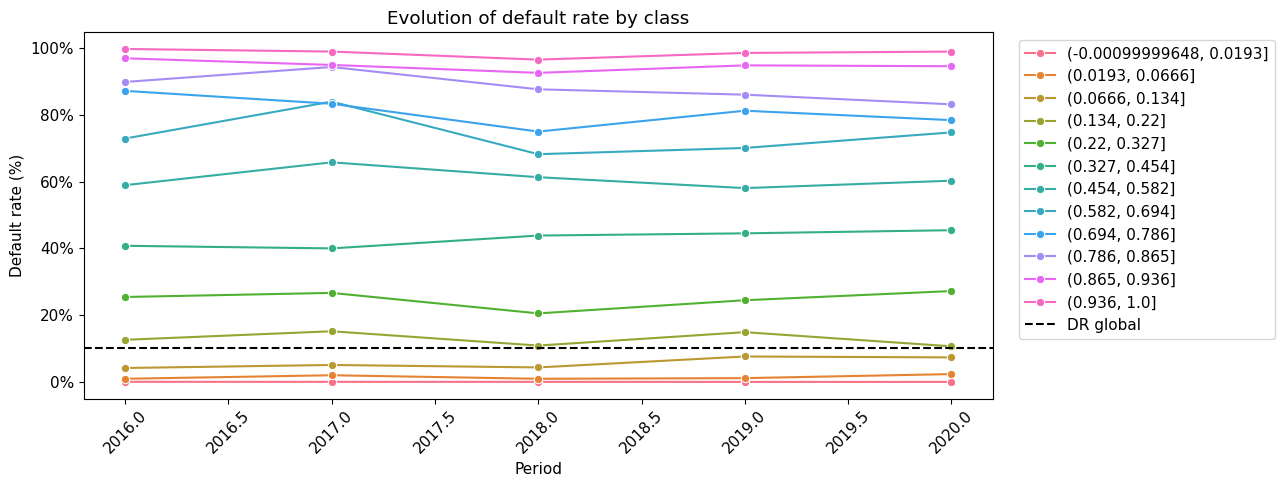

In [87]:
Bin_test.plot_bin_stability_over_time('CHR')

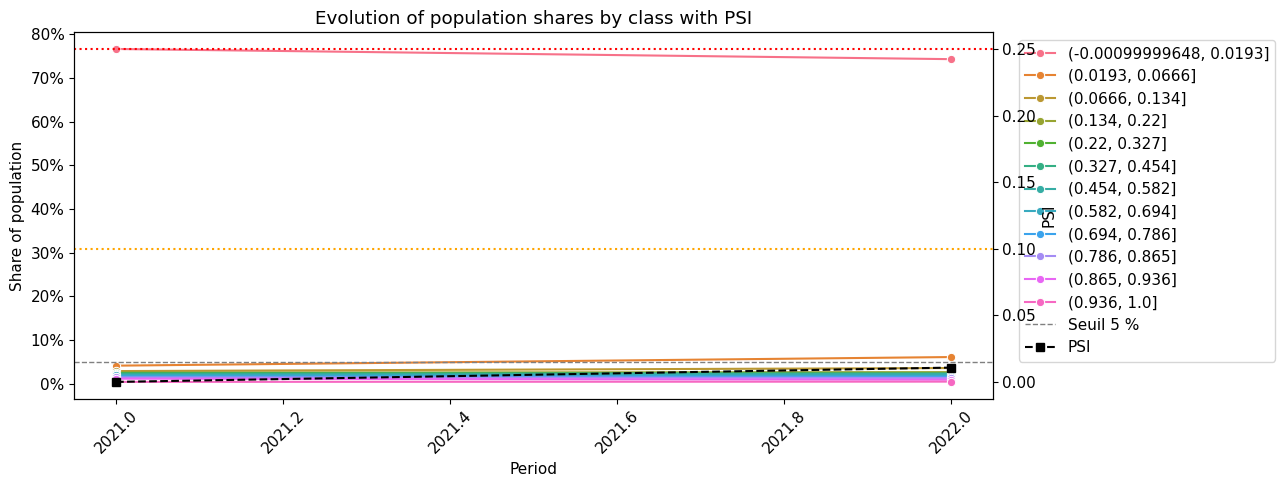

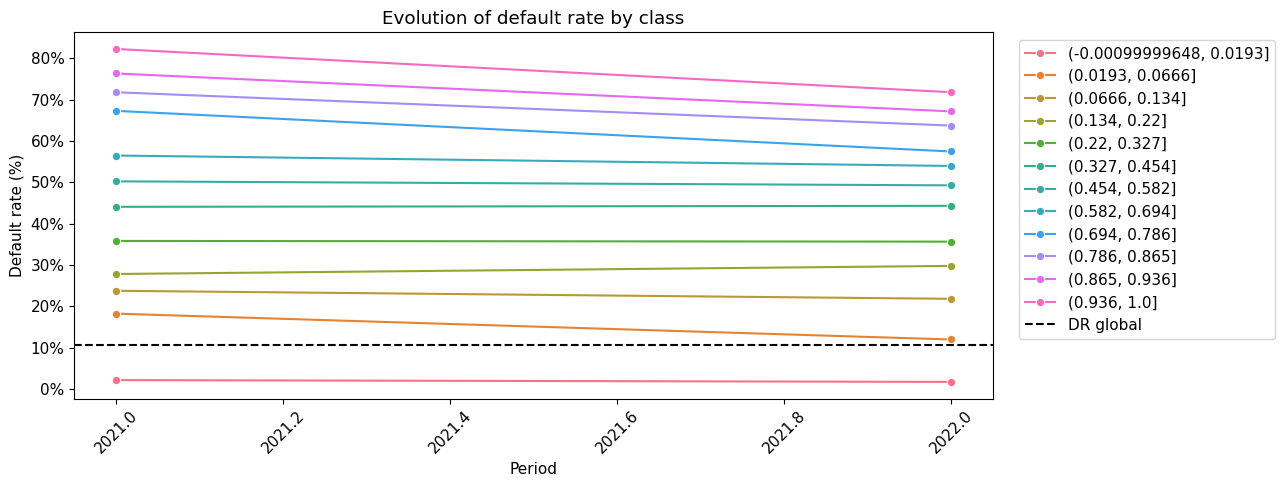

In [88]:
Bin_oot.plot_bin_stability_over_time('CHR')

In [89]:
oot_data.year.value_counts()

year
2022    77664
2021    38300
Name: count, dtype: int64